# PRODIGY INFOTECH

## Data Science Internship

### Task-03: Decision Tree Classifier

### Objective

Build a Decision Tree Classifier to predict whether a customer will subscribe to a term deposit based on demographic and behavioral data.

### Dataset

Bank Marketing Dataset (UCI Machine Learning Repository)

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("../data/bank-full.csv", sep=";")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (45211, 17)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [5]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [7]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [8]:
df.columns


Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

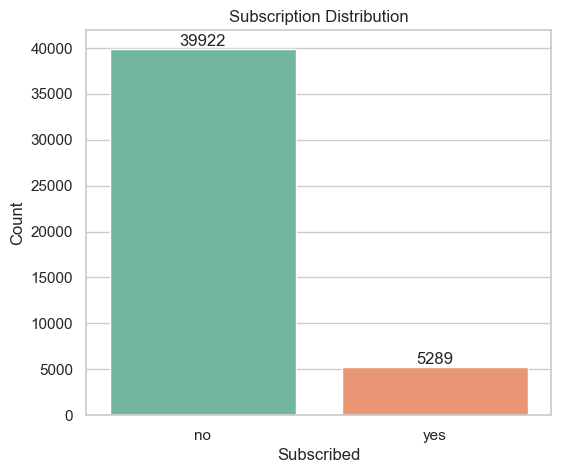

In [9]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    x="y",
    data=df,
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Subscription Distribution")
plt.xlabel("Subscribed")
plt.ylabel("Count")

plt.savefig("../images/subscription_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- Most customers did not subscribe to the term deposit.
- The dataset is imbalanced, with significantly more "No" responses than "Yes".

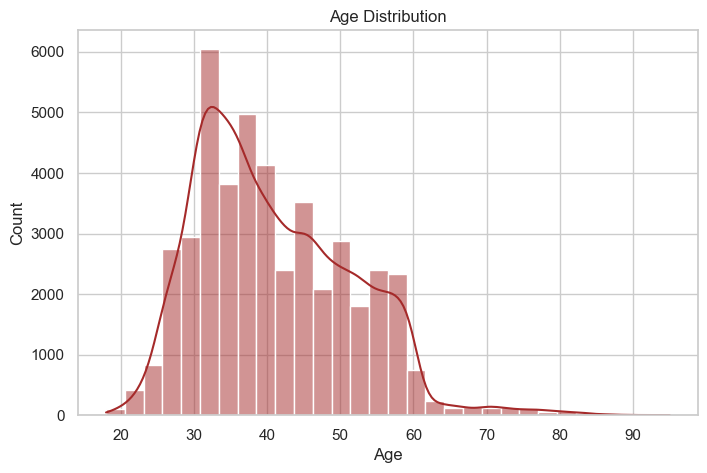

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    bins=30,
    kde=True,
    color="brown"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.savefig("../images/age_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- Most customers are between 30 and 50 years old.
- Very few customers are younger than 20 or older than 70.

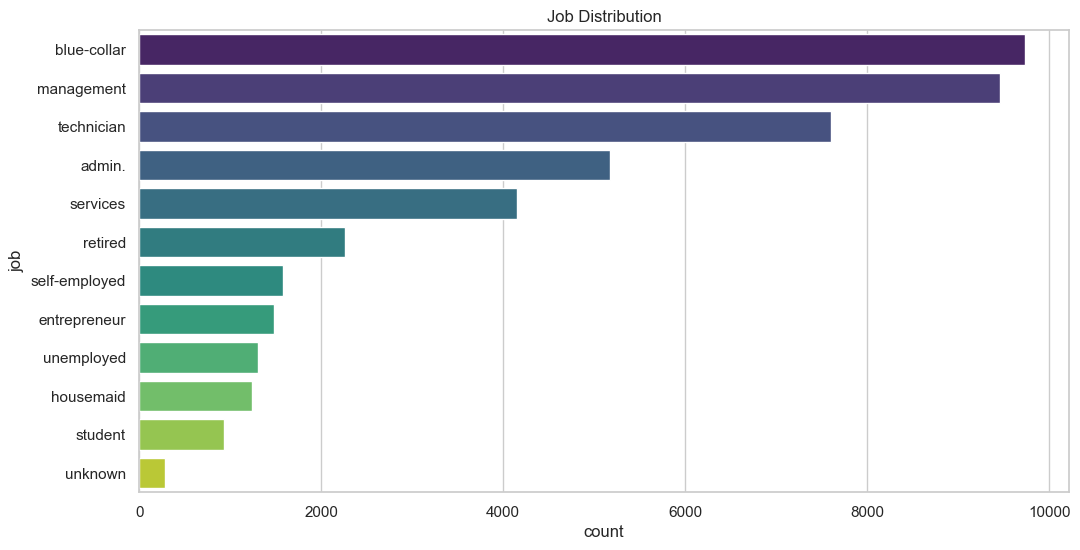

In [12]:
plt.figure(figsize=(12,6))

sns.countplot(
    y="job",
    data=df,
    order=df["job"].value_counts().index,
    palette="viridis"
)

plt.title("Job Distribution")

plt.savefig("../images/job_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- Blue-collar, management, and technician are among the most common occupations.
- Some job categories have relatively few customers.

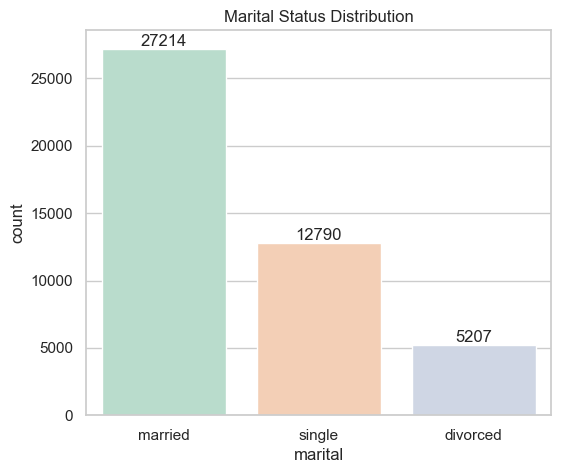

In [13]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    x="marital",
    data=df,
    palette="Pastel2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Marital Status Distribution")

plt.savefig("../images/marital_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- Married customers form the largest group.
- Single customers are the second largest segment.

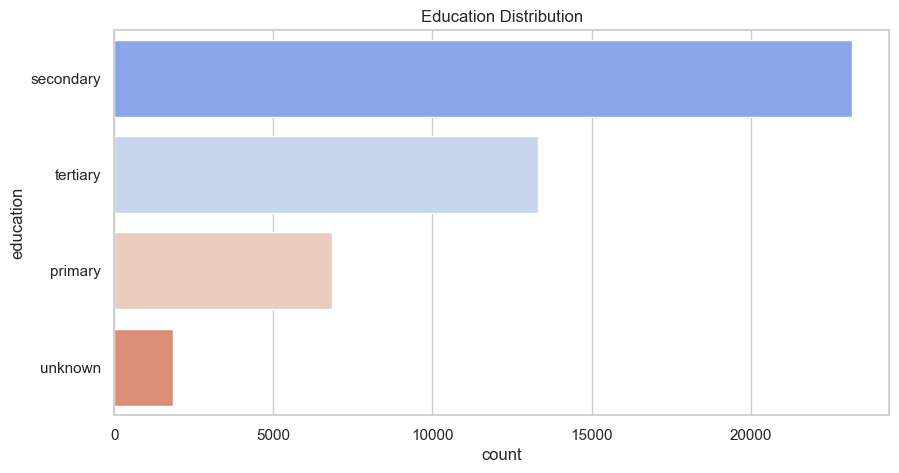

In [14]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="education",
    data=df,
    order=df["education"].value_counts().index,
    palette="coolwarm"
)

plt.title("Education Distribution")

plt.savefig("../images/education_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- Secondary education is the most common education level.
- Tertiary and primary education are also well represented.

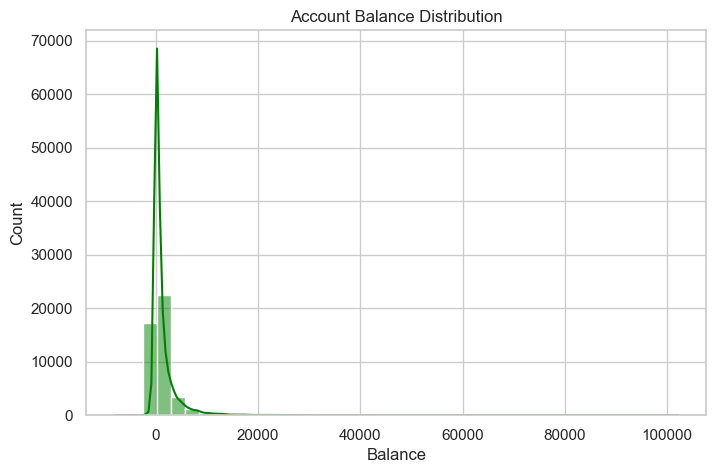

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["balance"],
    bins=40,
    kde=True,
    color="green"
)

plt.title("Account Balance Distribution")
plt.xlabel("Balance")

plt.savefig("../images/balance_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- Most customers have relatively low account balances.
- A few customers have exceptionally high balances.

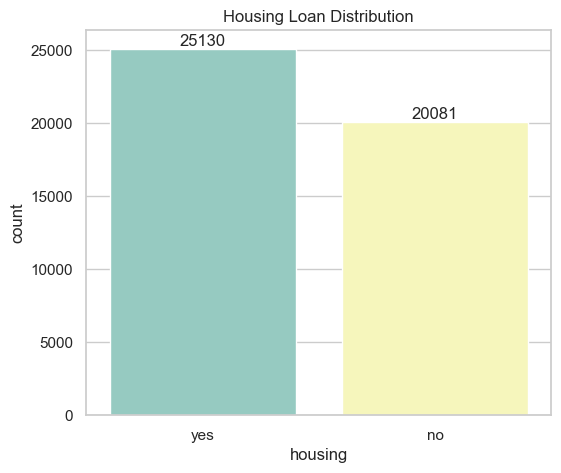

In [16]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    x="housing",
    data=df,
    palette="Set3"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Housing Loan Distribution")

plt.savefig("../images/housing_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- A large proportion of customers have housing loans.
- Customers without housing loans form a smaller group.

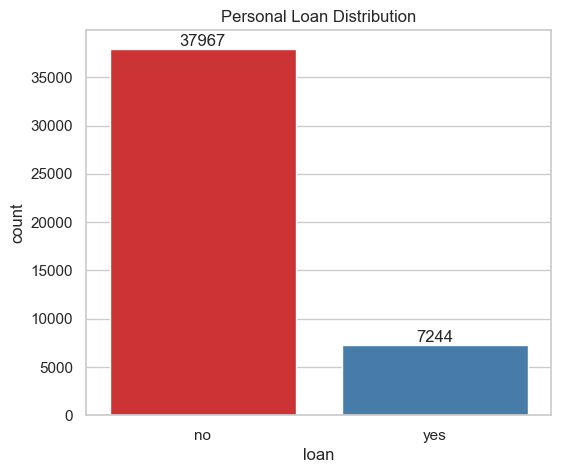

In [17]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    x="loan",
    data=df,
    palette="Set1"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Personal Loan Distribution")

plt.savefig("../images/loan_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- Most customers do not have personal loans.
- Only a small percentage have personal loans.

In [18]:
df_encoded = df.copy()

encoder = LabelEncoder()

for column in df_encoded.select_dtypes(include="object").columns:
    df_encoded[column] = encoder.fit_transform(df_encoded[column])

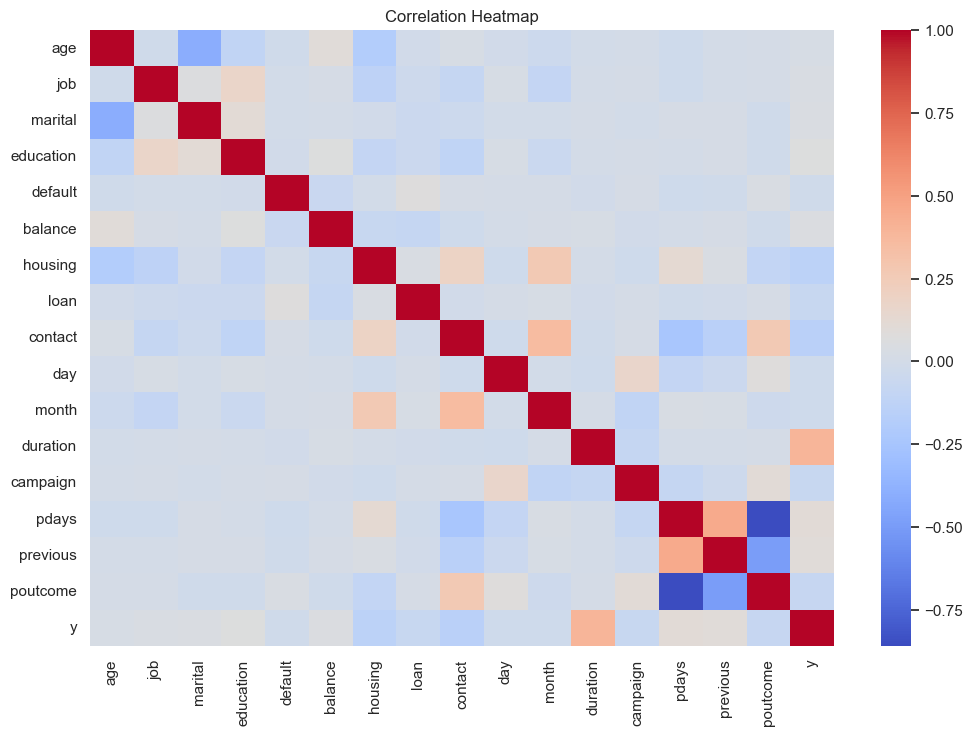

In [19]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_encoded.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.savefig("../images/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- Most features have weak correlations with one another.
- No strong multicollinearity is observed.

In [20]:
df_ml = df.copy()

encoder = LabelEncoder()

for column in df_ml.select_dtypes(include="object").columns:
    df_ml[column] = encoder.fit_transform(df_ml[column])

df_ml.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0


In [21]:
X = df_ml.drop("y", axis=1)
y = df_ml["y"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (45211, 16)
Target Shape: (45211,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (36168, 16)
Testing Samples  : (9043, 16)


In [23]:
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [24]:
y_pred = model.predict(X_test)

In [25]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = accuracy_score(y_test, y_pred)

print("Training Accuracy :", round(train_accuracy*100,2),"%")
print("Testing Accuracy  :", round(test_accuracy*100,2),"%")

Training Accuracy : 89.41 %
Testing Accuracy  : 88.49 %


### Observation

- The Decision Tree performs well on unseen data.
- Training and testing accuracy are compared to check for overfitting.

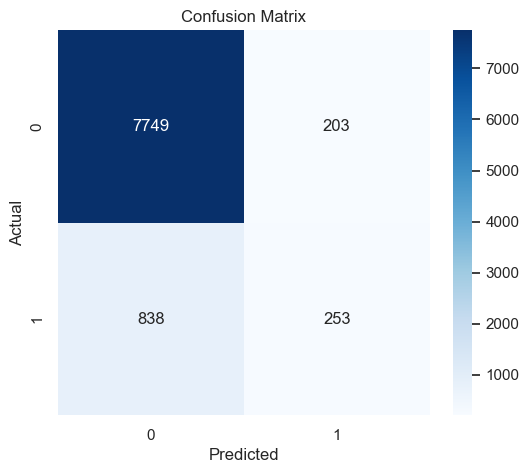

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../images/confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.97      0.94      7952
           1       0.55      0.23      0.33      1091

    accuracy                           0.88      9043
   macro avg       0.73      0.60      0.63      9043
weighted avg       0.86      0.88      0.86      9043



### Observation

- Precision, Recall and F1-score evaluate the classification performance.
- These metrics provide more insight than accuracy alone.

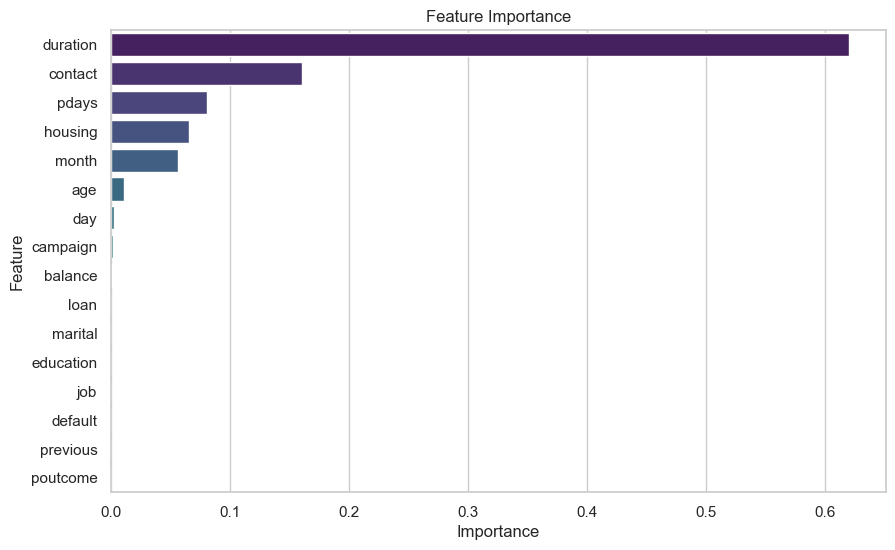

In [28]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance")

plt.savefig("../images/feature_importance.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Observation

- Duration is usually the most influential feature.
- Other important features include balance, age, and previous campaign information.

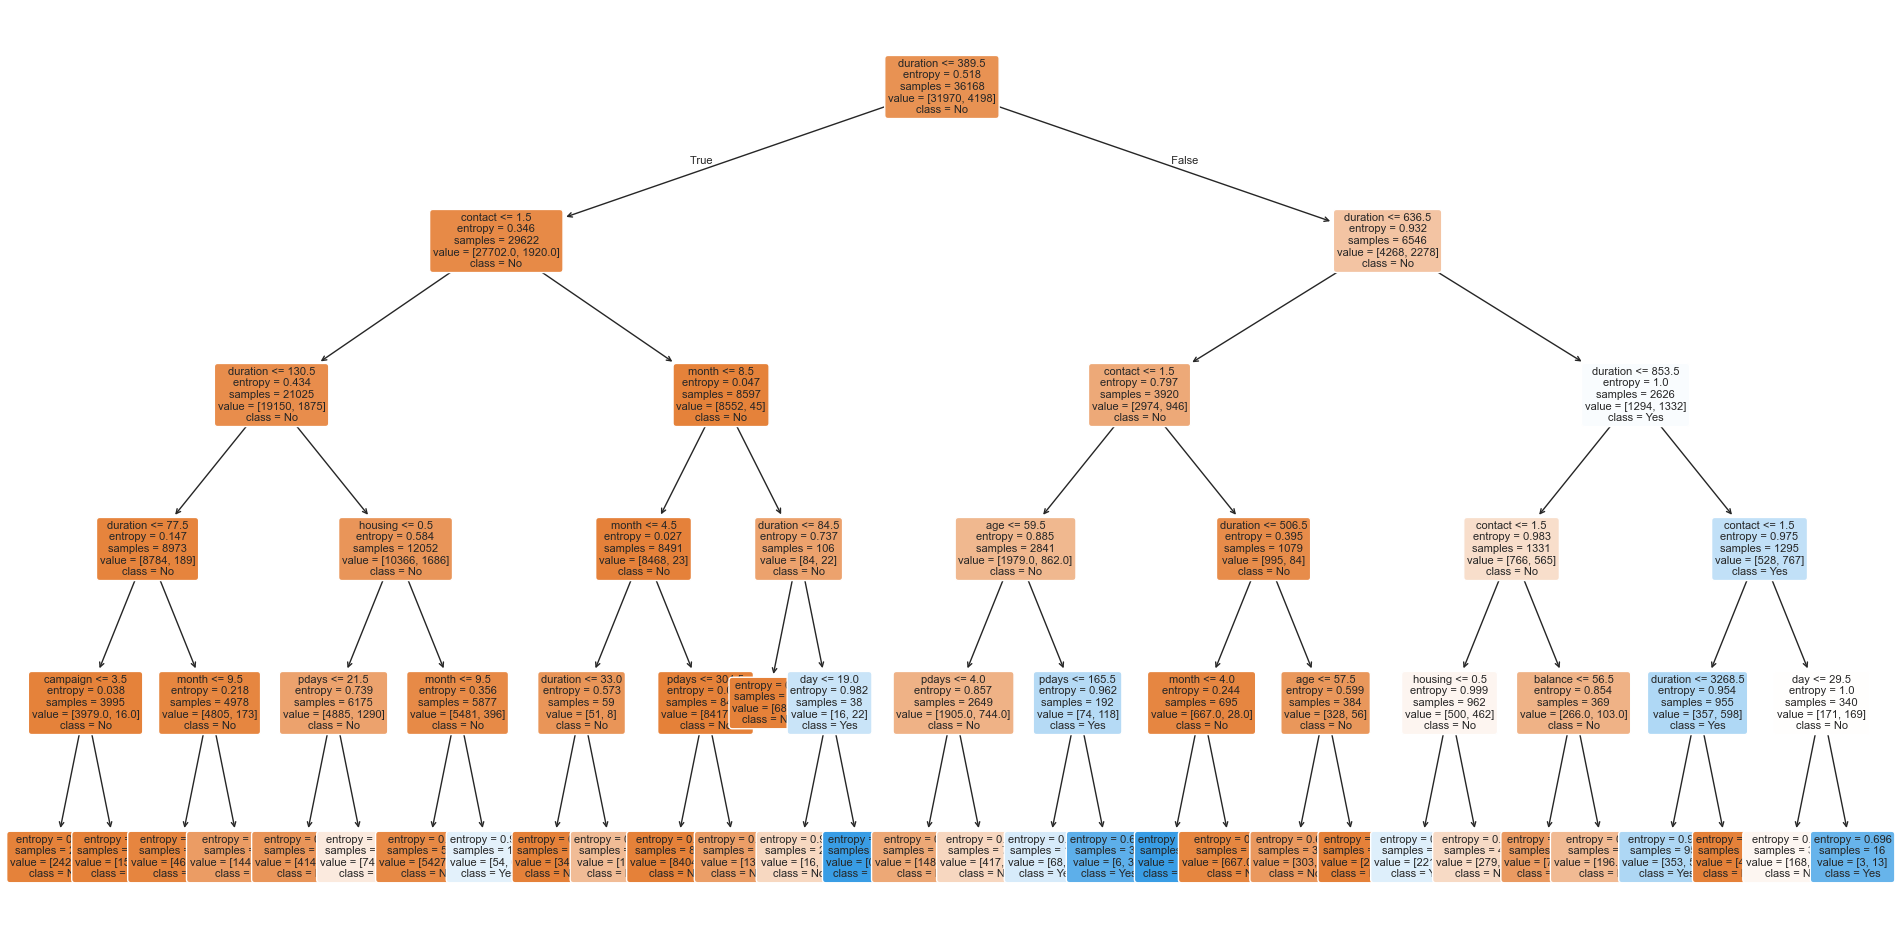

In [29]:
plt.figure(figsize=(24,12))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.savefig("../images/decision_tree.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Observation

- The Decision Tree visualizes how the model makes predictions.
- Each node represents a decision based on a feature.

Decision Tree Model Summary
Training Accuracy : 0.8941
Testing Accuracy  : 0.8849

Total Features : 16
Training Samples : 36168
Testing Samples : 9043
